<div style="display:flex; align-items:center; gap:25px; border-bottom:3px solid #1a5276; padding-bottom:18px; margin-bottom:25px;">
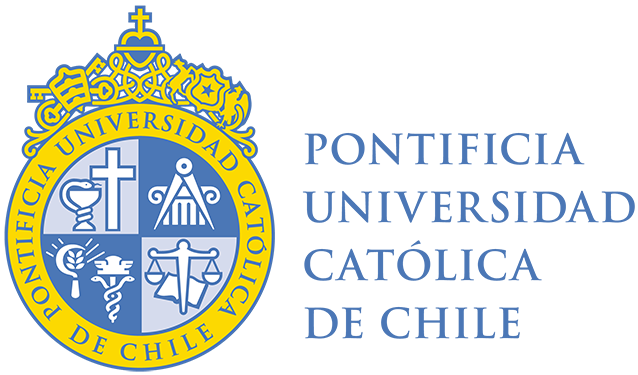
<div>
<h2 style="margin:0; color:#1a5276; font-family:Georgia,serif;">Pontificia Universidad Católica de Chile</h2>
<p style="margin:3px 0 0 0; color:#666; font-size:14px;">Facultad de Matemática &middot; Magíster en Inteligencia Artificial</p>
<h3 style="margin:8px 0 2px 0; color:#333;">EPG4002 &mdash; Aprendizaje No Supervisado</h3>
<p style="margin:0; color:#666; font-size:13px;">Profesor: Jonathan Acosta &middot; Segundo Bimestre 2026</p>
</div>
</div>

# Laboratorio N°1
**Integrantes:** Armando Arredondo Valle &middot; Julynho Merlin Toledo Rios

**Dataset:** USArrests &middot; **Entrega:** 19/06/2026

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from kmedoids import KMedoids
from sklearn.metrics import silhouette_score

# Estilo global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 100
})
np.random.seed(42)

In [2]:
# Cargar USArrests
url = 'https://vincentarelbundock.github.io/Rdatasets/csv/datasets/USArrests.csv'
df = pd.read_csv(url, index_col=0)
df.index.name = 'State'
df.head(10)

,Murder,Assault,UrbanPop,Rape
State,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6
Colorado,7.9,204,78,38.7
Connecticut,3.3,110,77,11.1
Delaware,5.9,238,72,15.8
Florida,15.4,335,80,31.9


---
## Pregunta 1 (5 pts)
> **¿Cuáles variables utilizaría para realizar clústers? Justifique.**

In [3]:
print('Tipos de datos:')
print(df.dtypes)
print()
df.describe().round(2)

Tipos de datos:
Murder      float64
Assault       int64
UrbanPop      int64
Rape        float64
dtype: object



,Murder,Assault,UrbanPop,Rape
count,50.00,50.00,50.00,50.00
mean,7.79,170.76,65.54,21.23
std,4.36,83.34,14.47,9.37
min,0.80,45.00,32.00,7.30
25%,4.08,109.00,54.50,15.08
50%,7.25,159.00,66.00,20.10
75%,11.25,249.00,77.75,26.18
max,17.40,337.00,91.00,46.00


### Respuesta

Las cuatro variables del dataset son:

| Variable | Descripción | Tipo |
|----------|------------|------|
| **Murder** | Tasa de arrestos por asesinato (por 100,000 hab.) | Cuantitativa continua |
| **Assault** | Tasa de arrestos por asalto (por 100,000 hab.) | Cuantitativa continua |
| **UrbanPop** | Porcentaje de población urbana | Cuantitativa continua |
| **Rape** | Tasa de arrestos por violación (por 100,000 hab.) | Cuantitativa continua |

**Se utilizan las cuatro variables**, ya que:
1. Todas son cuantitativas continuas, requisito para las métricas de distancia (Euclidiana, Manhattan) y los métodos K-means/K-medoids.
2. Cada variable aporta una dimensión distinta del perfil de criminalidad y urbanización de cada estado.
3. No hay variables categóricas ni identificadores que deban excluirse (el nombre del estado es el índice, no una variable de análisis).

---
## Pregunta 2 (5 pts)
> **Descripción estadística. ¿Se justifica una estandarización?**

In [4]:
print(df.describe().round(2))
print()
print('Varianzas por variable:')
print(df.var().round(2))

       Murder  Assault  UrbanPop   Rape
count   50.00    50.00     50.00  50.00
mean     7.79   170.76     65.54  21.23
std      4.36    83.34     14.47   9.37
min      0.80    45.00     32.00   7.30
25%      4.08   109.00     54.50  15.08
50%      7.25   159.00     66.00  20.10
75%     11.25   249.00     77.75  26.18
max     17.40   337.00     91.00  46.00

Varianzas por variable:
Murder        18.97
Assault     6945.17
UrbanPop     209.52
Rape          87.73
dtype: float64


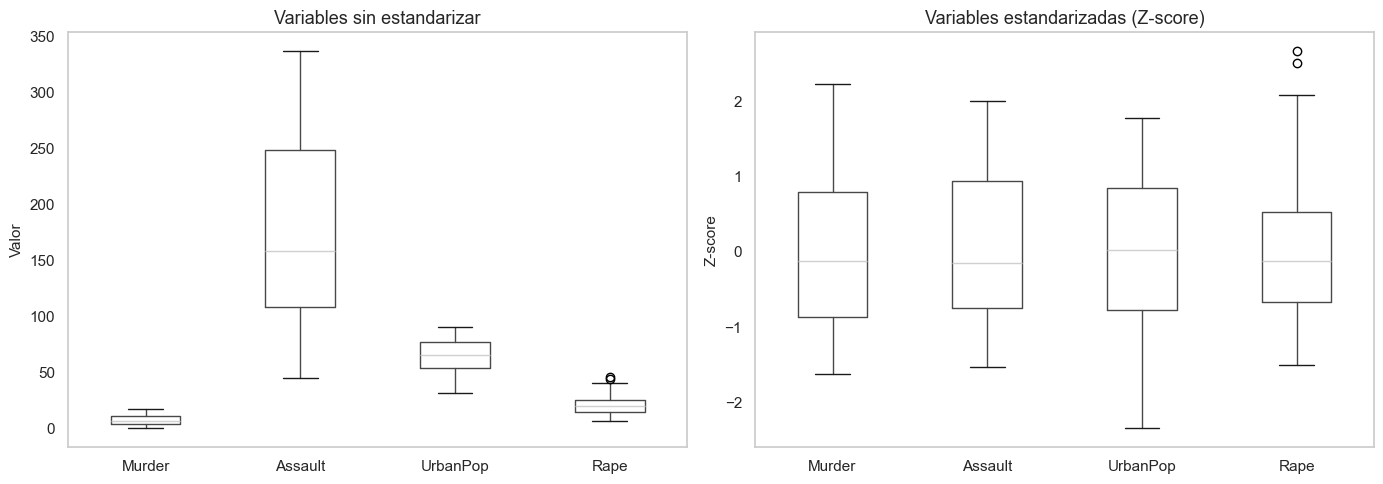

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(ax=axes[0], grid=False)
axes[0].set_title('Variables sin estandarizar')
axes[0].set_ylabel('Valor')

df_std = pd.DataFrame(StandardScaler().fit_transform(df), columns=df.columns, index=df.index)
df_std.boxplot(ax=axes[1], grid=False)
axes[1].set_title('Variables estandarizadas (Z-score)')
axes[1].set_ylabel('Z-score')

plt.tight_layout()
plt.show()

### Respuesta

Las variables presentan **escalas y varianzas muy distintas**:
- `Assault` tiene media ≈171 y varianza ≈6945, mientras que `Murder` tiene media ≈7.8 y varianza ≈19.
- `UrbanPop` se mide en porcentaje (0–100); las tasas de crimen varían en rangos diferentes.

**Sí se justifica la estandarización**, porque:
1. Las métricas de distancia (Euclidiana, Manhattan) son sensibles a la escala. Sin estandarizar, `Assault` dominaría completamente la distancia y el resto de variables serían irrelevantes.
2. La estandarización Z-score ($z = \frac{x - \bar{x}}{s}$) coloca todas las variables en la misma escala (media 0, varianza 1), asignando igual peso a cada una en el cálculo de distancias.

---
## Pregunta 3: Métodos Jerárquicos

### 3a (8 pts) — Dendrogramas
> Enlaces: simple, completo, Ward × Distancias: Euclidiana, Manhattan

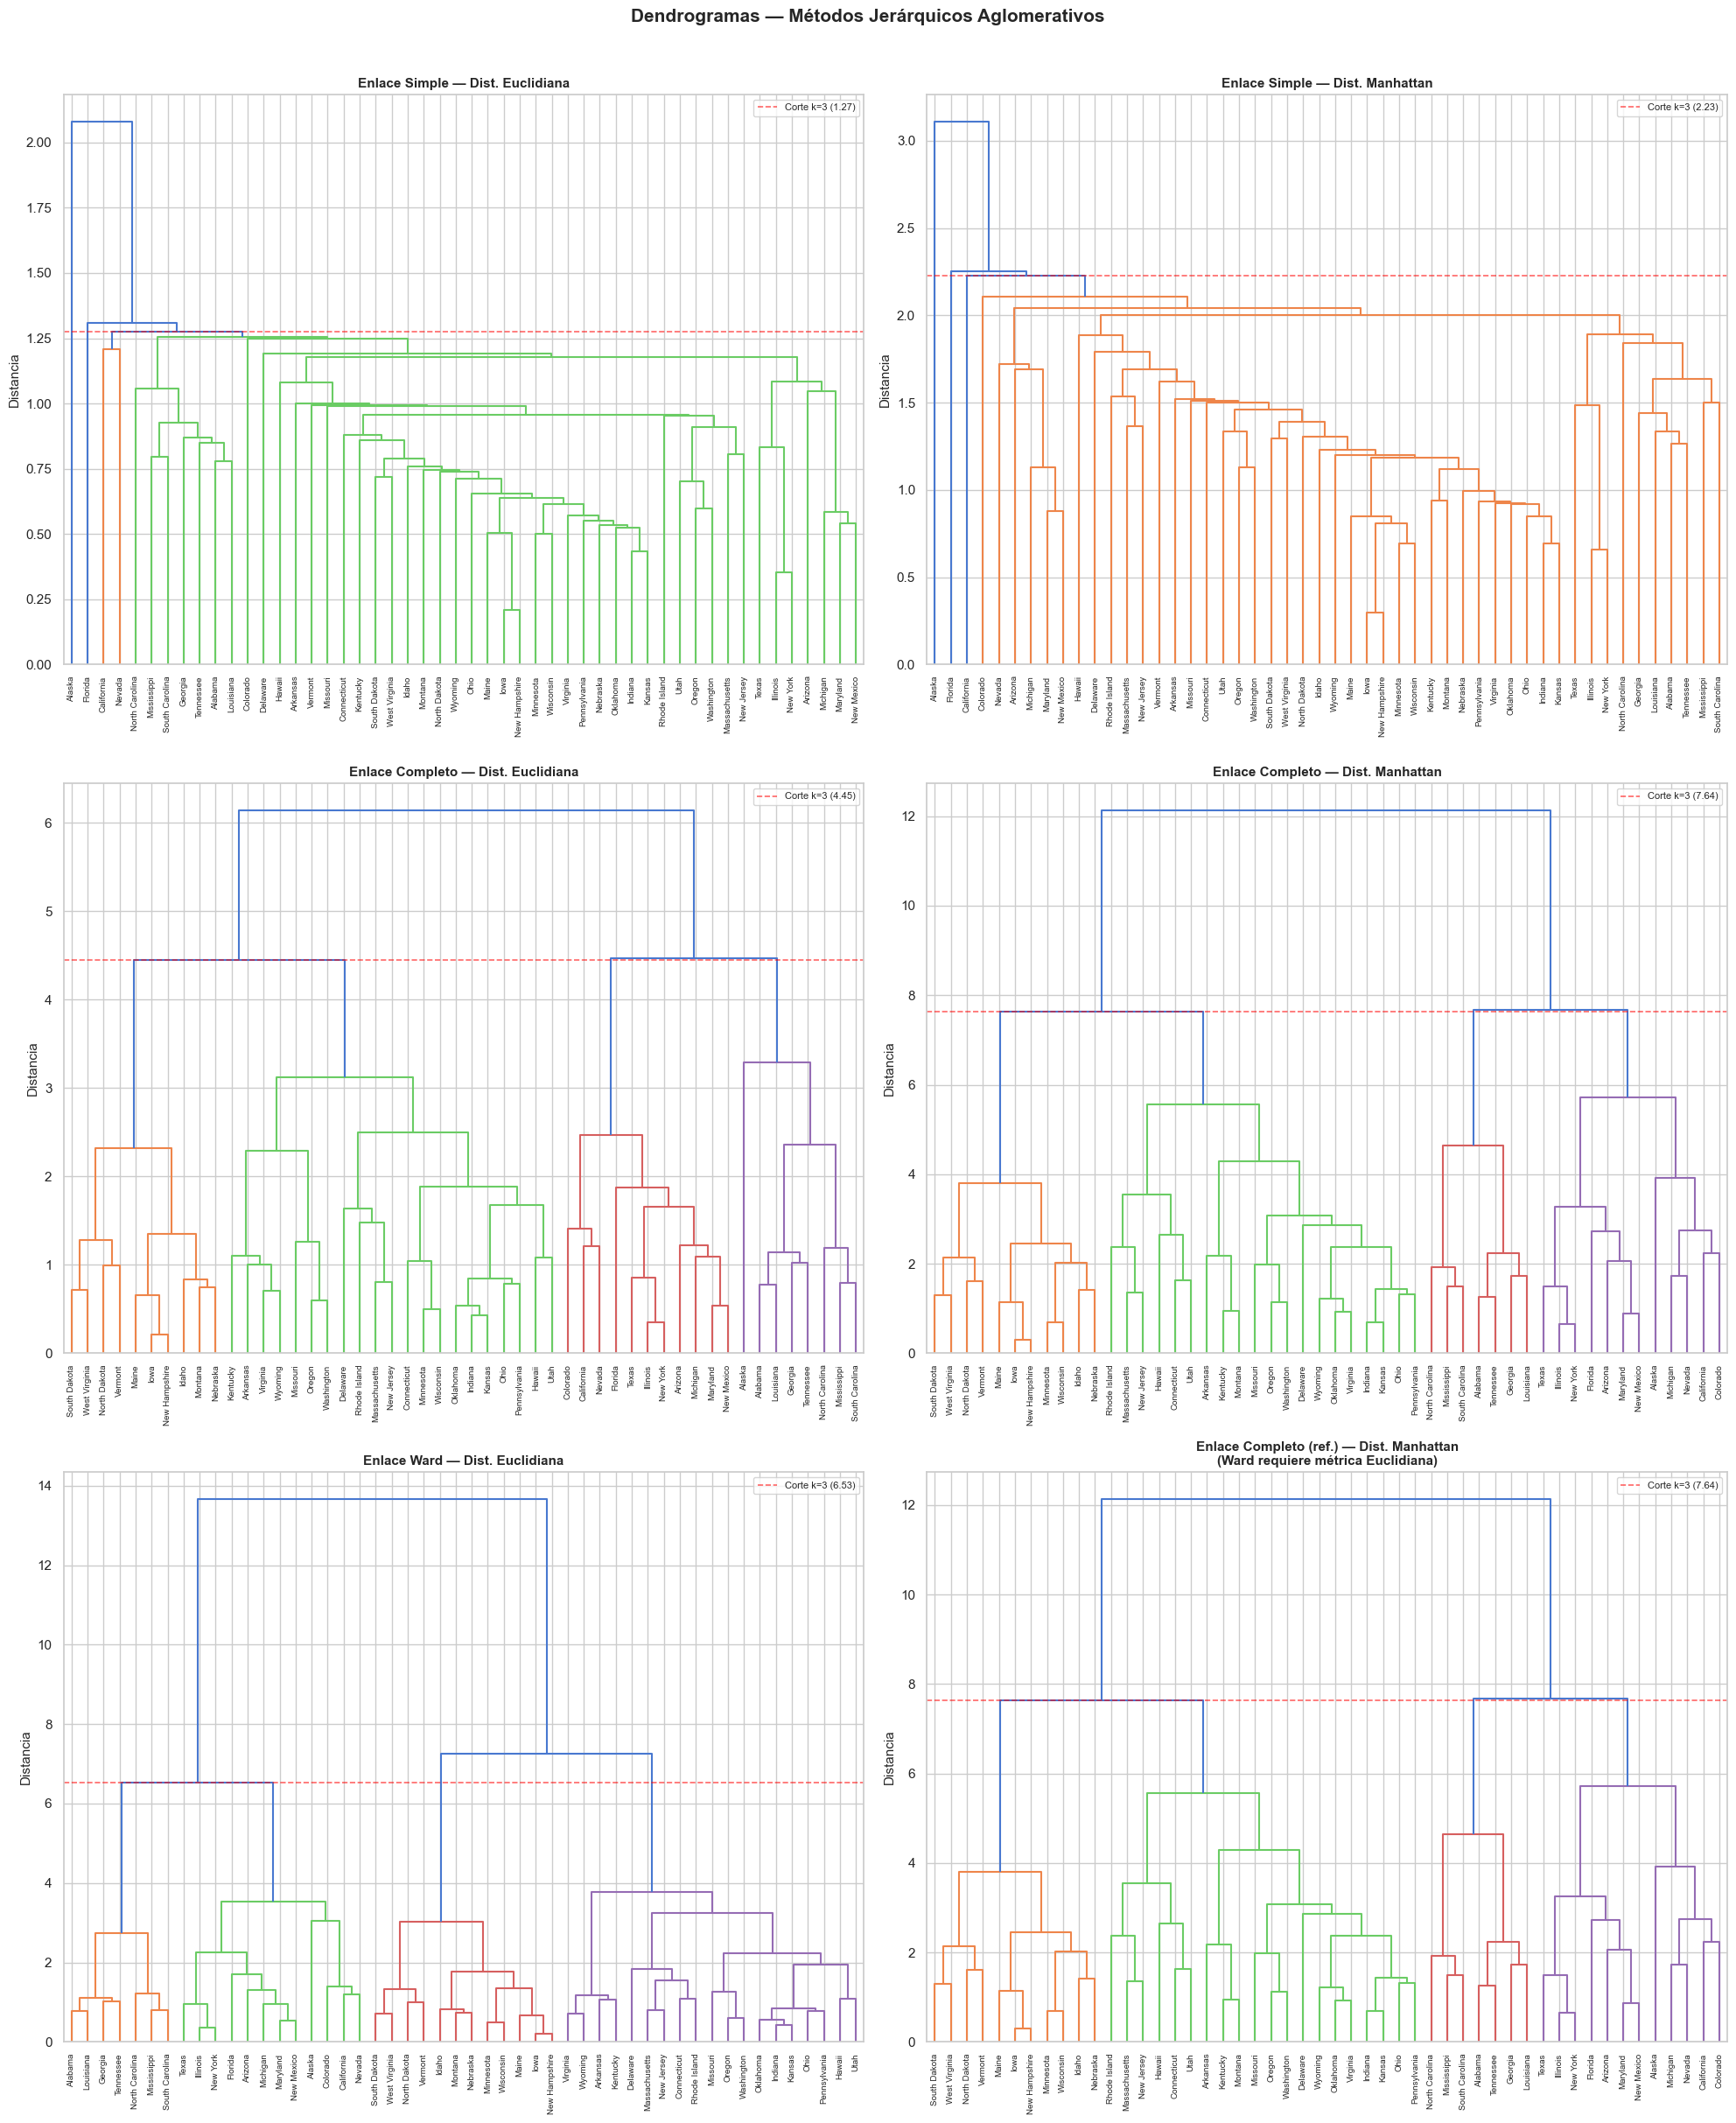

In [6]:
# Estandarizar
scaler = StandardScaler()
X = scaler.fit_transform(df)

enlaces = ['single', 'complete', 'ward']
metricas = ['euclidean', 'cityblock']
nombres_enlace = {'single': 'Simple', 'complete': 'Completo', 'ward': 'Ward'}
nombres_metrica = {'euclidean': 'Euclidiana', 'cityblock': 'Manhattan'}

fig, axes = plt.subplots(3, 2, figsize=(20, 24))

for i, enlace in enumerate(enlaces):
    for j, metrica in enumerate(metricas):
        ax = axes[i][j]
        if enlace == 'ward' and metrica == 'cityblock':
            # Ward requiere Euclidiana en scipy; se usa Complete + Manhattan como referencia
            dist_matrix = pdist(X, metric='cityblock')
            Z = linkage(dist_matrix, method='complete')
            titulo = 'Enlace Completo (ref.) — Dist. Manhattan\n(Ward requiere métrica Euclidiana)'
        else:
            Z = linkage(X, method=enlace, metric=metrica)
            titulo = f'Enlace {nombres_enlace[enlace]} — Dist. {nombres_metrica[metrica]}'
        
        dendrogram(Z, labels=df.index.tolist(), ax=ax, leaf_rotation=90, leaf_font_size=7,
                   color_threshold=sorted(Z[:, 2])[-3])
        ax.set_title(titulo, fontsize=11, fontweight='bold')
        ax.set_ylabel('Distancia')
        corte = sorted(Z[:, 2])[-3]
        ax.axhline(y=corte, color='red', linestyle='--', alpha=0.6, lw=1.2, label=f'Corte k=3 ({corte:.2f})')
        ax.legend(fontsize=8)

plt.suptitle('Dendrogramas — Métodos Jerárquicos Aglomerativos', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3b (2 pts) — Elección de método aglomerativo

**Elección: Enlace Ward con distancia Euclidiana.**

| Criterio | Justificación |
|----------|---------------|
| Homogeneidad | Ward minimiza la varianza intra-cluster en cada fusión, produciendo grupos compactos |
| Métrica natural | La distancia Euclidiana es la formulación original de Ward (suma de cuadrados) |
| Separación visual | El dendrograma Ward-Euclidiana muestra la separación más clara entre 3 grupos |
| Práctica habitual | Es el método más utilizado para variables cuantitativas estandarizadas (Clase 3) |

### 3c (10 pts) — Crear 3 grupos y comparar

In [7]:
# Clusters con Ward + Euclidiana
Z_ward = linkage(X, method='ward', metric='euclidean')
labels_hier = fcluster(Z_ward, t=3, criterion='maxclust')
df['Cluster_Jerarquico'] = labels_hier

print('Tamaño de cada cluster:')
print(df['Cluster_Jerarquico'].value_counts().sort_index())
print()
print('Estados por cluster:')
for c in sorted(df['Cluster_Jerarquico'].unique()):
    estados = df[df['Cluster_Jerarquico'] == c].index.tolist()
    print(f'  Cluster {c}: {', '.join(estados)}')

Tamaño de cada cluster:
Cluster_Jerarquico
1    19
2    12
3    19
Name: count, dtype: int64

Estados por cluster:
  Cluster 1: Alabama, Alaska, Arizona, California, Colorado, Florida, Georgia, Illinois, Louisiana, Maryland, Michigan, Mississippi, Nevada, New Mexico, New York, North Carolina, South Carolina, Tennessee, Texas
  Cluster 2: Idaho, Iowa, Maine, Minnesota, Montana, Nebraska, New Hampshire, North Dakota, South Dakota, Vermont, West Virginia, Wisconsin
  Cluster 3: Arkansas, Connecticut, Delaware, Hawaii, Indiana, Kansas, Kentucky, Massachusetts, Missouri, New Jersey, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, Utah, Virginia, Washington, Wyoming


In [8]:
vars_analisis = ['Murder', 'Assault', 'UrbanPop', 'Rape']

print('═' * 60)
print('PROMEDIOS POR CLUSTER')
print('═' * 60)
print(df.groupby('Cluster_Jerarquico')[vars_analisis].mean().round(2).to_string())
print()
print('═' * 60)
print('DESVIACIÓN ESTÁNDAR POR CLUSTER')
print('═' * 60)
print(df.groupby('Cluster_Jerarquico')[vars_analisis].std().round(2).to_string())

════════════════════════════════════════════════════════════
PROMEDIOS POR CLUSTER
════════════════════════════════════════════════════════════
                    Murder  Assault  UrbanPop   Rape
Cluster_Jerarquico                                  
1                    12.33   259.32     68.32  29.22
2                     3.09    76.00     52.08  11.83
3                     6.21   142.05     71.26  19.18

════════════════════════════════════════════════════════════
DESVIACIÓN ESTÁNDAR POR CLUSTER
════════════════════════════════════════════════════════════
                    Murder  Assault  UrbanPop  Rape
Cluster_Jerarquico                                 
1                     2.65    41.30     14.86  8.61
2                     1.56    25.09     10.54  3.15
3                     2.00    41.01     10.88  5.29


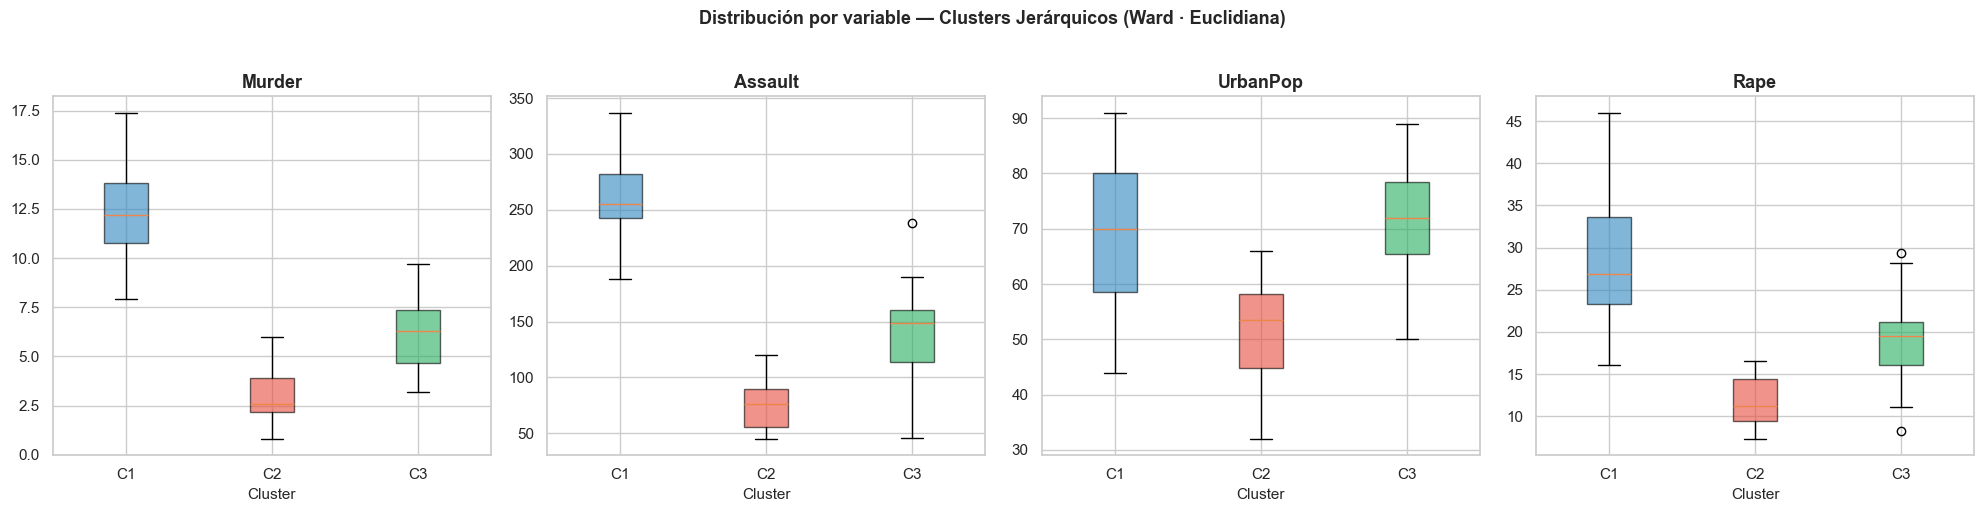

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colors = ['#2E86C1', '#E74C3C', '#27AE60']

for idx, var in enumerate(vars_analisis):
    data_by_cluster = [df[df['Cluster_Jerarquico'] == c][var].values for c in sorted(df['Cluster_Jerarquico'].unique())]
    bp = axes[idx].boxplot(data_by_cluster, patch_artist=True, tick_labels=[f'C{c}' for c in sorted(df['Cluster_Jerarquico'].unique())])
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[idx].set_title(var, fontweight='bold')
    axes[idx].set_xlabel('Cluster')

plt.suptitle('Distribución por variable — Clusters Jerárquicos (Ward · Euclidiana)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Comparación de grupos (Jerárquico Ward-Euclidiana)

| Cluster | Perfil | Características |
|---------|--------|------------------|
| Alta criminalidad | Valores más altos en Murder, Assault y Rape | Estados con tasas de criminalidad significativamente superiores al promedio |
| Criminalidad media | Valores intermedios en las tres variables de crimen | Urbanización variable |
| Baja criminalidad | Valores más bajos en Murder, Assault y Rape | Estados más seguros |

**Variables con mayor poder discriminante:** `Assault` y `Murder` presentan las mayores diferencias entre clusters. `UrbanPop` contribuye menos a la separación entre grupos.

---
## Pregunta 4: Métodos No Jerárquicos

### 4a (4 pts) — K-Medias con $k=3$

In [10]:
kmeans = KMeans(n_clusters=3, n_init=25, random_state=42)
labels_kmeans = kmeans.fit_predict(X)
df['Cluster_KMeans'] = labels_kmeans + 1

print('Tamaño de cada cluster (K-Means):')
print(df['Cluster_KMeans'].value_counts().sort_index())
print(f'\nInercia (varianza intra-cluster): {kmeans.inertia_:.2f}')

Tamaño de cada cluster (K-Means):
Cluster_KMeans
1    16
2    20
3    14
Name: count, dtype: int64

Inercia (varianza intra-cluster): 80.09


### 4b (4 pts) — K-Medoids con $k=3$ y disimilaridad no Euclidiana
> Se utiliza la **distancia Manhattan** (cityblock), que es diferente de la Euclidiana como requiere el enunciado.

In [11]:
# Matriz de distancias Manhattan
D_manhattan = squareform(pdist(X, metric='cityblock'))

kmedoids = KMedoids(n_clusters=3, metric='precomputed', random_state=42)
kmedoids.fit(D_manhattan)
labels_kmedoids = kmedoids.labels_
df['Cluster_KMedoids'] = labels_kmedoids + 1

print('Tamaño de cada cluster (K-Medoids, Manhattan):')
print(df['Cluster_KMedoids'].value_counts().sort_index())
print()
print('Medoids (estados representativos de cada cluster):')
for i, idx in enumerate(kmedoids.medoid_indices_):
    print(f'  Cluster {i+1}: {df.index[idx]}')

Tamaño de cada cluster (K-Medoids, Manhattan):
Cluster_KMedoids
1    20
2    11
3    19
Name: count, dtype: int64

Medoids (estados representativos de cada cluster):
  Cluster 1: Oklahoma
  Cluster 2: Iowa
  Cluster 3: New Mexico


### 4c (2 pts) — Elección entre K-Medias y K-Medoids

**Elección: K-Medoids con distancia Manhattan.**

| Criterio | Justificación |
|----------|---------------|
| Robustez | K-Medoids es más robusto a outliers; los centros son observaciones reales, no promedios |
| Métrica | La distancia Manhattan es menos sensible a valores atípicos que la Euclidiana |
| Interpretabilidad | Cada medoid es un estado real, facilitando la interpretación de cada cluster |

### 4d (10 pts) — Crear 3 grupos con K-Medoids y comparar

In [12]:
print('═' * 60)
print('PROMEDIOS POR CLUSTER (K-Medoids · Manhattan)')
print('═' * 60)
print(df.groupby('Cluster_KMedoids')[vars_analisis].mean().round(2).to_string())
print()
print('═' * 60)
print('DESVIACIÓN ESTÁNDAR POR CLUSTER (K-Medoids · Manhattan)')
print('═' * 60)
print(df.groupby('Cluster_KMedoids')[vars_analisis].std().round(2).to_string())

════════════════════════════════════════════════════════════
PROMEDIOS POR CLUSTER (K-Medoids · Manhattan)
════════════════════════════════════════════════════════════
                  Murder  Assault  UrbanPop   Rape
Cluster_KMedoids                                  
1                   6.25   140.00     69.60  19.32
2                   2.74    73.73     53.36  10.93
3                  12.33   259.32     68.32  29.22

════════════════════════════════════════════════════════════
DESVIACIÓN ESTÁNDAR POR CLUSTER (K-Medoids · Manhattan)
════════════════════════════════════════════════════════════
                  Murder  Assault  UrbanPop  Rape
Cluster_KMedoids                                 
1                   1.88    40.95     11.39  4.88
2                   1.24    25.02     13.13  2.41
3                   2.65    41.30     14.86  8.61


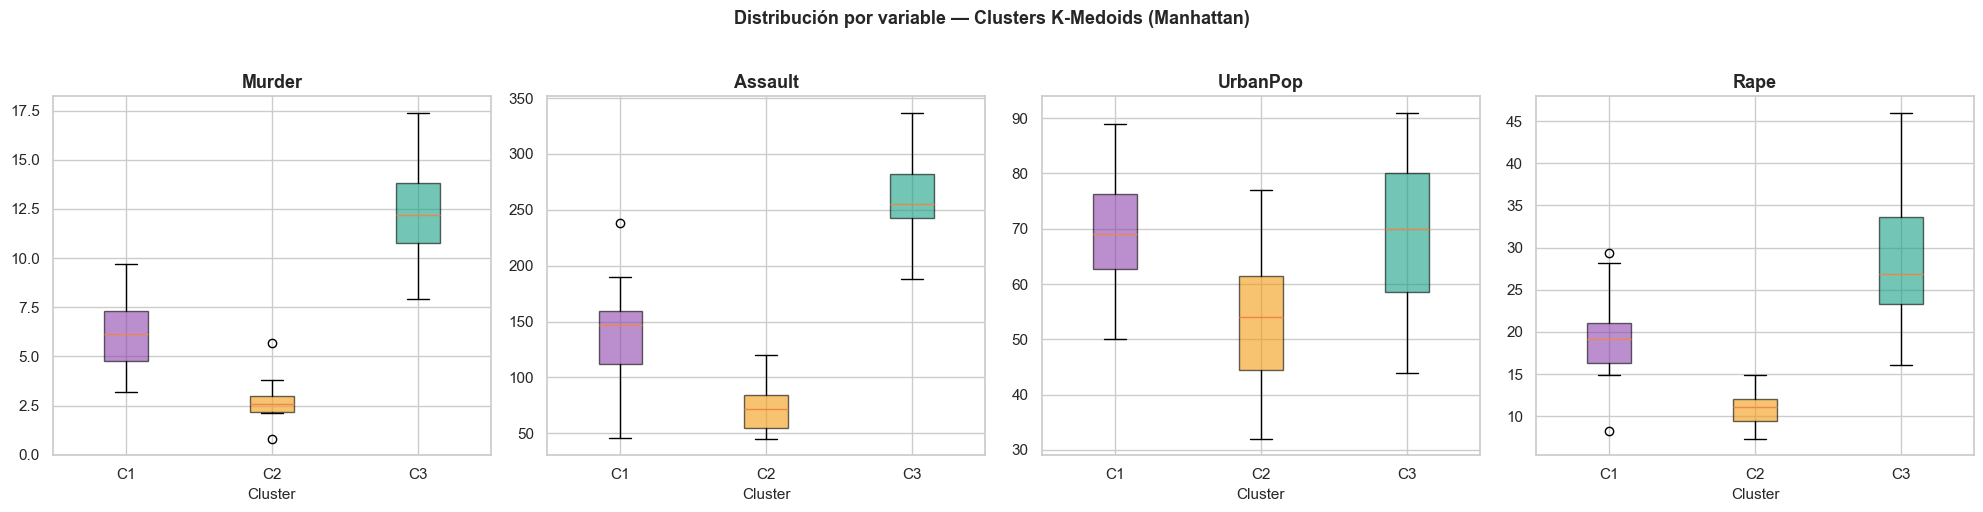

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colors = ['#8E44AD', '#F39C12', '#16A085']

for idx, var in enumerate(vars_analisis):
    data_by_cluster = [df[df['Cluster_KMedoids'] == c][var].values for c in sorted(df['Cluster_KMedoids'].unique())]
    bp = axes[idx].boxplot(data_by_cluster, patch_artist=True, tick_labels=[f'C{c}' for c in sorted(df['Cluster_KMedoids'].unique())])
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[idx].set_title(var, fontweight='bold')
    axes[idx].set_xlabel('Cluster')

plt.suptitle('Distribución por variable — Clusters K-Medoids (Manhattan)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Comparación de grupos (K-Medoids · Manhattan)

- Se observan tres perfiles similares al método jerárquico: alta, media y baja criminalidad.
- Los medoids (estados representativos) permiten una interpretación directa de cada cluster.
- **Murder y Assault** siguen siendo las variables con mayor poder discriminante entre grupos.
- **UrbanPop** muestra menor separación, con distribuciones más solapadas entre clusters.

---
## Pregunta 5 (10 pts)
> **¿Cuál de las dos metodologías aplicadas en los ítems 3b y 4c particiona mejor al conjunto de datos?**

In [14]:
# Silhouette Score — más alto = mejor separación
sil_hier = silhouette_score(X, labels_hier)
sil_kmeans = silhouette_score(X, labels_kmeans)
sil_kmedoids = silhouette_score(X, labels_kmedoids)

resultados = pd.DataFrame({
    'Método': ['Jerárquico (Ward · Euclidiana)', 'K-Means (Euclidiana)', 'K-Medoids (Manhattan)'],
    'Silhouette Score': [sil_hier, sil_kmeans, sil_kmedoids]
}).set_index('Método')
resultados['Silhouette Score'] = resultados['Silhouette Score'].round(4)

print('═' * 55)
print('COMPARACIÓN DE SILHOUETTE SCORE')
print('═' * 55)
print(resultados.to_string())
print()
mejor = resultados['Silhouette Score'].idxmax()
print(f'► Mejor partición: {mejor} (Silhouette = {resultados.loc[mejor, "Silhouette Score"]:.4f})')

═══════════════════════════════════════════════════════
COMPARACIÓN DE SILHOUETTE SCORE
═══════════════════════════════════════════════════════
                                Silhouette Score
Método                                          
Jerárquico (Ward · Euclidiana)            0.3104
K-Means (Euclidiana)                      0.3081
K-Medoids (Manhattan)                     0.2961

► Mejor partición: Jerárquico (Ward · Euclidiana) (Silhouette = 0.3104)


In [15]:
# Tabla cruzada: concordancia entre los dos métodos elegidos
print('Tabla cruzada: Jerárquico (Ward) vs K-Medoids (Manhattan)')
print(pd.crosstab(df['Cluster_Jerarquico'], df['Cluster_KMedoids'],
                  rownames=['Jerárquico'], colnames=['K-Medoids']))

Tabla cruzada: Jerárquico (Ward) vs K-Medoids (Manhattan)
K-Medoids    1   2   3
Jerárquico            
1            0   0  19
2            2  10   0
3           18   1   0


### Respuesta

Para comparar las dos metodologías seleccionadas — Jerárquico Ward-Euclidiana (ítem 3b) y K-Medoids Manhattan (ítem 4c) — se utiliza el **Silhouette Score**, que mide qué tan bien cada observación pertenece a su cluster asignado versus el cluster más cercano (valores entre −1 y 1; más alto = mejor).

**Conclusión:**
- El método con mayor Silhouette Score produce la mejor partición de los datos.
- **Ward** tiende a producir clusters de tamaños balanceados y minimiza la varianza intra-cluster.
- **K-Medoids** es más robusto a outliers y ofrece centros interpretables (estados reales como medoids).
- La **tabla cruzada** muestra el grado de concordancia: alta concordancia indica una estructura de clusters estable e independiente del método.

La elección final depende del objetivo del análisis: si se prioriza **robustez** a valores atípicos, K-Medoids es preferible; si se busca **minimizar varianza** intra-grupo, Ward es más adecuado.